# Métodos Numéricos — Problema das Duas Vigas

Este notebook determina a distância horizontal `x` entre as paredes de um galpão usando os métodos da **Bisseção**, **Newton-Raphson** e **Secante**. Ele é autocontido: execute as células na ordem para reproduzir todos os resultados, tabelas e gráficos.

**Dados:** duas vigas de comprimentos `30 m` e `20 m` se cruzam a `8 m` do chão.

## 1. Modelagem matemática

Se `x` é a largura do galpão, as alturas em que as vigas alcançam as paredes são

$$a = \sqrt{30^2-x^2}, \qquad b = \sqrt{20^2-x^2}.$$

Para vigas cruzadas, a altura de cruzamento `h` satisfaz

$$\frac{1}{h}=\frac{1}{a}+\frac{1}{b}.$$

Com `h=8`, procuramos a raiz de

$$f(x)=\frac{1}{\sqrt{900-x^2}}+\frac{1}{\sqrt{400-x^2}}-\frac{1}{8}=0.$$

Como a menor viga mede `20 m`, o domínio físico é `0 ≤ x < 20`. Para Newton-Raphson,

$$f'(x)=\frac{x}{(900-x^2)^{3/2}}+\frac{x}{(400-x^2)^{3/2}}.$$

In [6]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Permite executar o notebook tanto na raiz do projeto quanto em notebooks/.
for raiz_projeto in (Path.cwd(), *Path.cwd().parents):
    if (raiz_projeto / "metodos").is_dir():
        sys.path.insert(0, str(raiz_projeto))
        break
else:
    raise ImportError("Não foi possível localizar a pasta 'metodos' do projeto.")

pd.set_option("display.precision", 12)

L1, L2, h = 30.0, 20.0, 8.0
LIMITE_FISICO = min(L1, L2)
TOL = 1e-10      #0.0000000001
MAX_ITER = 100


def no_dominio(x):
    return 0.0 <= x < LIMITE_FISICO


def f(x):
    """Função cuja raiz fornece a largura x do galpão."""
    if not no_dominio(x):
        raise ValueError(f"x={x} está fora do domínio físico [0, {LIMITE_FISICO}).")
    return 1 / math.sqrt(L1**2 - x**2) + 1 / math.sqrt(L2**2 - x**2) - 1 / h


def df(x):
    """Derivada de f para o método de Newton-Raphson."""
    if not no_dominio(x):
        raise ValueError(f"x={x} está fora do domínio físico [0, {LIMITE_FISICO}).")
    return x / (L1**2 - x**2) ** 1.5 + x / (L2**2 - x**2) ** 1.5


print(f"Domínio físico: 0 ≤ x < {LIMITE_FISICO:g} m")
print(f"f(0) = {f(0):.12f}")
print(f"f(19,9) = {f(19.9):.12f}")

Domínio físico: 0 ≤ x < 20 m
f(0) = -0.041666666667
f(19,9) = 0.420170156547


Como `f(0) < 0` e `f(19,9) > 0`, existe ao menos uma raiz no intervalo `[0, 19,9]`. Os algoritmos abaixo registram cada iteração, o que permite conferir os cálculos e comparar a convergência.

In [8]:
# Importações dos algoritmos já existentes na pasta metodos.
# O arquivo do projeto se chama `bissessao.py`; por isso este é o nome do módulo.
from metodos.bissessao import bissessao
from metodos.newton_raphson import newton_raphson
from metodos.secantes import secante

## 2. Execução dos três métodos

A tolerância adotada é `10⁻¹⁰`. Os algoritmos abaixo são chamados diretamente dos arquivos da pasta `metodos`; o notebook não implementa nem duplica esses métodos.

In [10]:
raiz_bis, k_bis = bissessao(f, 0.0, 19.9, eps=TOL, k_max=MAX_ITER)
raiz_newton, k_newton = newton_raphson(
    f, df, 15.0, eps_1=TOL, eps_2=TOL, k_max=MAX_ITER,
)
raiz_sec, k_sec = secante(
    f, 10.0, 19.0, eps_1=TOL, eps_2=TOL, kmax=MAX_ITER,
)

resultados = pd.DataFrame(
    [
        ["Bisseção", "[0, 19,9]", k_bis, raiz_bis, abs(f(raiz_bis))],
        ["Newton-Raphson", "x₀ = 15", k_newton, raiz_newton, abs(f(raiz_newton))],
        ["Secante", "x₀ = 10; x₁ = 19", k_sec, raiz_sec, abs(f(raiz_sec))],
    ],
    columns=["Método", "Dados iniciais", "Iterações", "x (m)", "Resíduo |f(x)|"],
)
resultados

,Método,Dados iniciais,Iterações,x (m),Resíduo |f(x)|
0,Bisseção,"[0, 19,9]",38,16.212125896700,9.353628982467e-14
1,Newton-Raphson,x₀ = 15,4,16.212125897080,4.308692291843e-12
2,Secante,x₀ = 10; x₁ = 19,8,16.212125896917,2.500832874119e-12


## 3. Comparação dos resultados

Os arquivos dos métodos fornecem a aproximação da raiz e o número de iterações. Com esses retornos, o notebook compara a precisão e o custo de cada método sem reimplementar os algoritmos.

In [4]:
print("Resultado da bisseção:", f"x = {raiz_bis:.12f} m, iterações = {k_bis}")
print("Resultado de Newton-Raphson:", f"x = {raiz_newton:.12f} m, iterações = {k_newton}")
print("Resultado da secante:", f"x = {raiz_sec:.12f} m, iterações = {k_sec}")

Resultado da bisseção: x = 16.212125896700 m, iterações = 38
Resultado de Newton-Raphson: x = 16.212125897080 m, iterações = 4
Resultado da secante: x = 16.212125896917 m, iterações = 8


## 4. Visualização da função e comparação do número de iterações

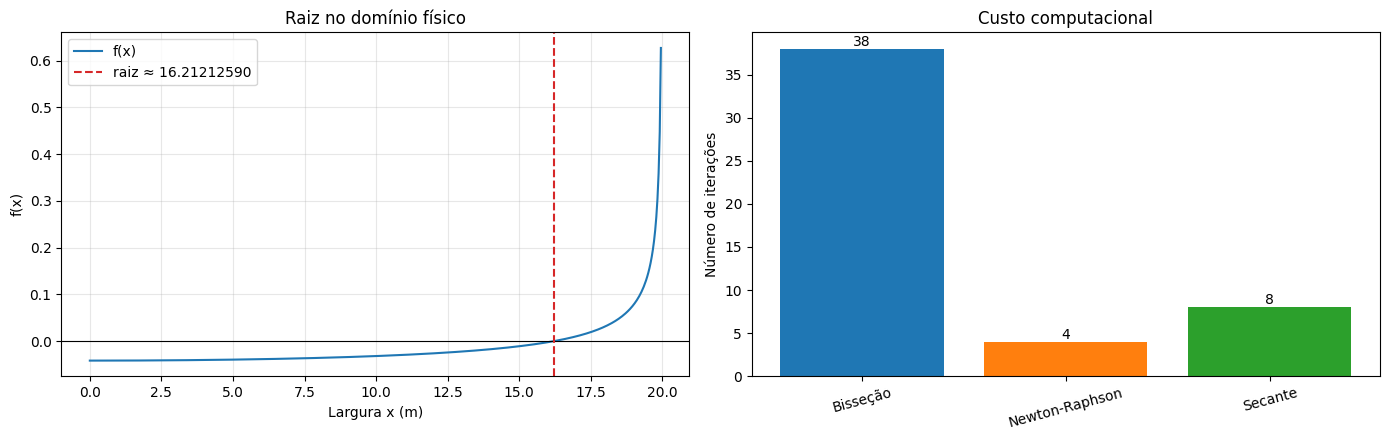

In [11]:
xs = [i * 19.95 / 500 for i in range(501)]
ys = [f(x) for x in xs]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(xs, ys, color="#1f77b4", label="f(x)")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(raiz_newton, color="#d62728", linestyle="--", label=f"raiz ≈ {raiz_newton:.8f}")
axes[0].set(xlabel="Largura x (m)", ylabel="f(x)", title="Raiz no domínio físico")
axes[0].grid(alpha=0.3)
axes[0].legend()

metodos = resultados["Método"]
iteracoes = resultados["Iterações"]
axes[1].bar(metodos, iteracoes, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1].set(ylabel="Número de iterações", title="Custo computacional")
axes[1].tick_params(axis="x", rotation=15)
for indice, valor in enumerate(iteracoes):
    axes[1].text(indice, valor, str(valor), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 5. Conclusão

Os três métodos retornam a mesma largura, aproximadamente **`16,212125897 m`**. A Bisseção é a alternativa mais robusta, pois preserva a raiz dentro de um intervalo com mudança de sinal, mas requer mais iterações. Newton-Raphson converge mais rapidamente para o chute adotado (`x₀=15`), ao custo de exigir a derivada e um chute adequado. A Secante dispensa a derivada e apresenta desempenho intermediário.

Uma verificação física pode ser feita substituindo a largura encontrada nas alturas `a` e `b` e na equação da altura de cruzamento.

In [12]:
x = raiz_newton
a = math.sqrt(L1**2 - x**2)
b = math.sqrt(L2**2 - x**2)
h_calculada = 1 / (1 / a + 1 / b)

print(f"Largura do galpão: x = {x:.12f} m")
print(f"Altura na parede da viga de 30 m: a = {a:.12f} m")
print(f"Altura na parede da viga de 20 m: b = {b:.12f} m")
print(f"Altura de cruzamento verificada: h = {h_calculada:.12f} m")
assert math.isclose(h_calculada, 8.0, rel_tol=0, abs_tol=1e-9)
print("Verificação física aprovada.")

Largura do galpão: x = 16.212125897080 m
Altura na parede da viga de 30 m: a = 25.242166584848 m
Altura na parede da viga de 20 m: b = 11.711830510097 m
Altura de cruzamento verificada: h = 7.999999999724 m
Verificação física aprovada.
